In [1]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt

In [2]:
seg_vol = np.load("/home/ubuntu/code/ffn/results/fib25/training2/0/0/seg-0_0_0.npz")
image_vol = np.array(h5.File("/home/ubuntu/code/ffn/third_party/neuroproof_examples/training_sample2/grayscale_maps.h5", mode='r')['raw'])

In [81]:
groundtruth = h5.File("/home/ubuntu/code/ffn/third_party/neuroproof_examples/training_sample2/groundtruth.h5", mode='r')
groundtruth_arr = np.array(groundtruth['stack'])

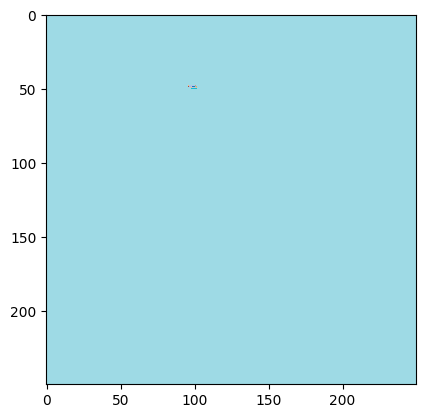

In [86]:
plt.imshow(groundtruth_arr[,:,:], cmap='tab20')

In [3]:
seg = seg_vol['segmentation']
seg.shape

(250, 250, 250)

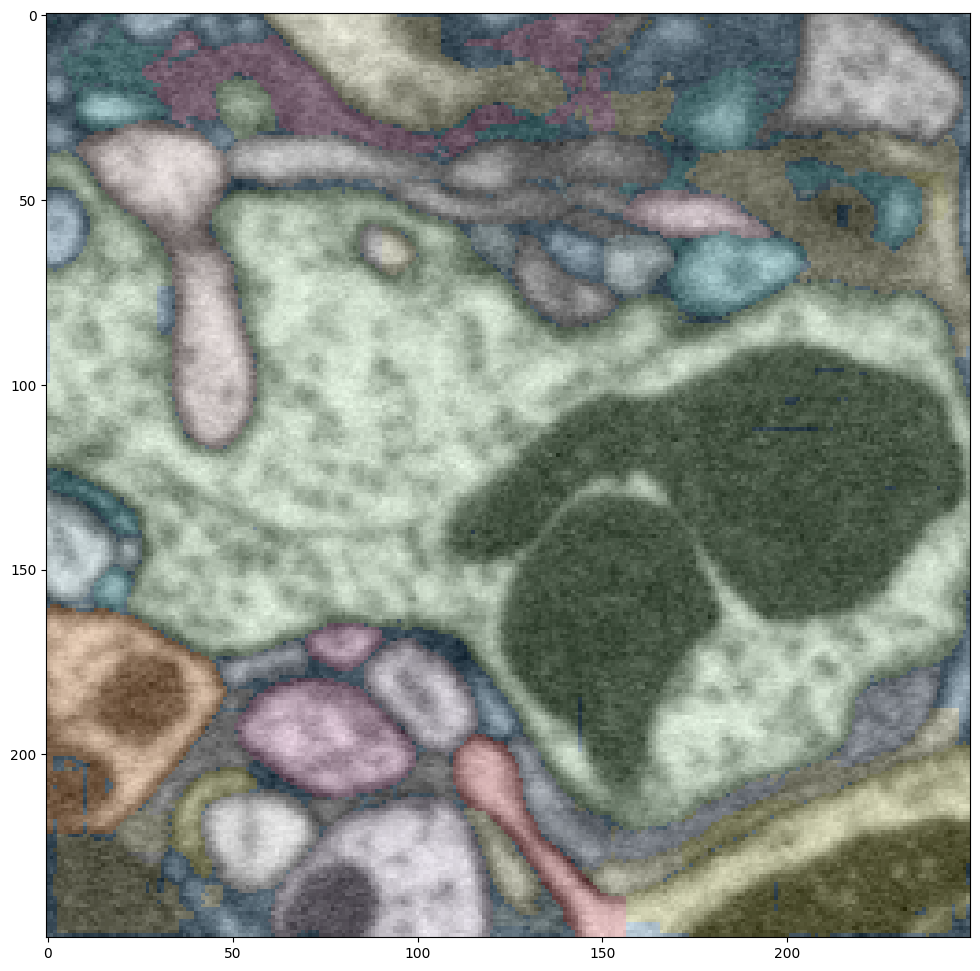

In [71]:
frame = 200
plt.figure(1, figsize=(12,12))
plt.imshow(image_vol[frame,:,:], cmap='gray')
plt.imshow(seg[frame,:,:], cmap='tab20', alpha=0.2)

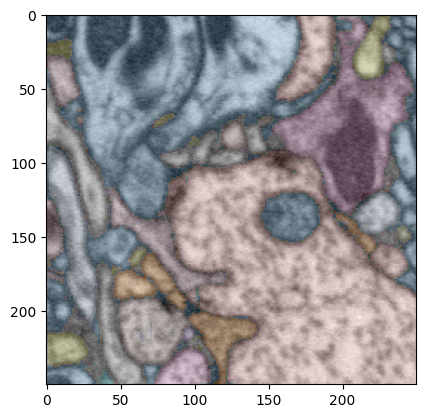

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Set up the figure
fig, ax = plt.subplots()
image_display = ax.imshow(image_vol[125, :, :], cmap='gray')
seg_display = ax.imshow(seg[125, :, :], cmap='tab20', alpha=0.2)

def update(frame):
    """Update the image and segmentation displays for a given frame index."""
    image_display.set_data(image_vol[frame, :, :])
    seg_display.set_data(seg[frame, :, :])
    ax.set_title(f"Slice: {frame}")
    return image_display, seg_display

# Create animation
ani = FuncAnimation(fig, update, frames=image_vol.shape[0], interval=500)  # 500 ms between frames

plt.show()

## Colon Ramos Volume

In [ ]:
worm = np.load("/home/ubuntu/code/colonramos_compresses.npz")

image_array = worm['data']

cropped_image = np.squeeze(image_array[:250, :250, :250])
cropped_image.shape

hf = h5.File('colonramos_cropped.h5', 'w')

hf.create_dataset('raw', data=cropped_image)
hf.close()

In [56]:
colonramos_seg = np.load("/home/ubuntu/code/ffn/results/colonramos/cropped/0/0/seg-0_0_0.npz")['segmentation']

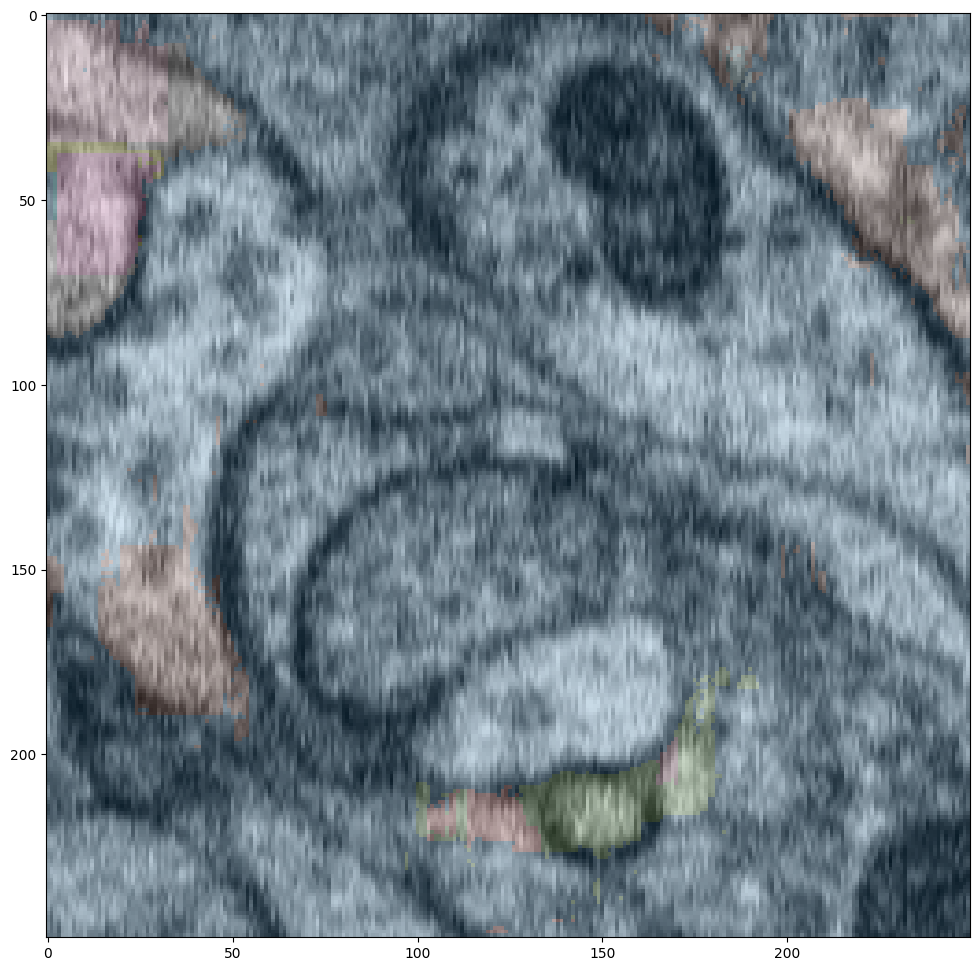

In [74]:
frame = 180
plt.figure(1, figsize=(12,12))
plt.imshow(cropped_image[frame,:,:], cmap='gray')
plt.imshow(colonramos_seg[frame,:,], cmap='tab20', alpha=0.2)

## Transposed volume!

In [64]:
cropped_image_zyx = cropped_image.T
hf = h5.File('colonramos_cropped_zyx.h5', 'w')

hf.create_dataset('raw', data=cropped_image_zyx)
hf.close()

In [53]:
colonramos_seg_zyx = np.load("/home/ubuntu/code/ffn/results/colonramos/cropped_zyx/0/0/seg-0_0_0.npz")['segmentation']

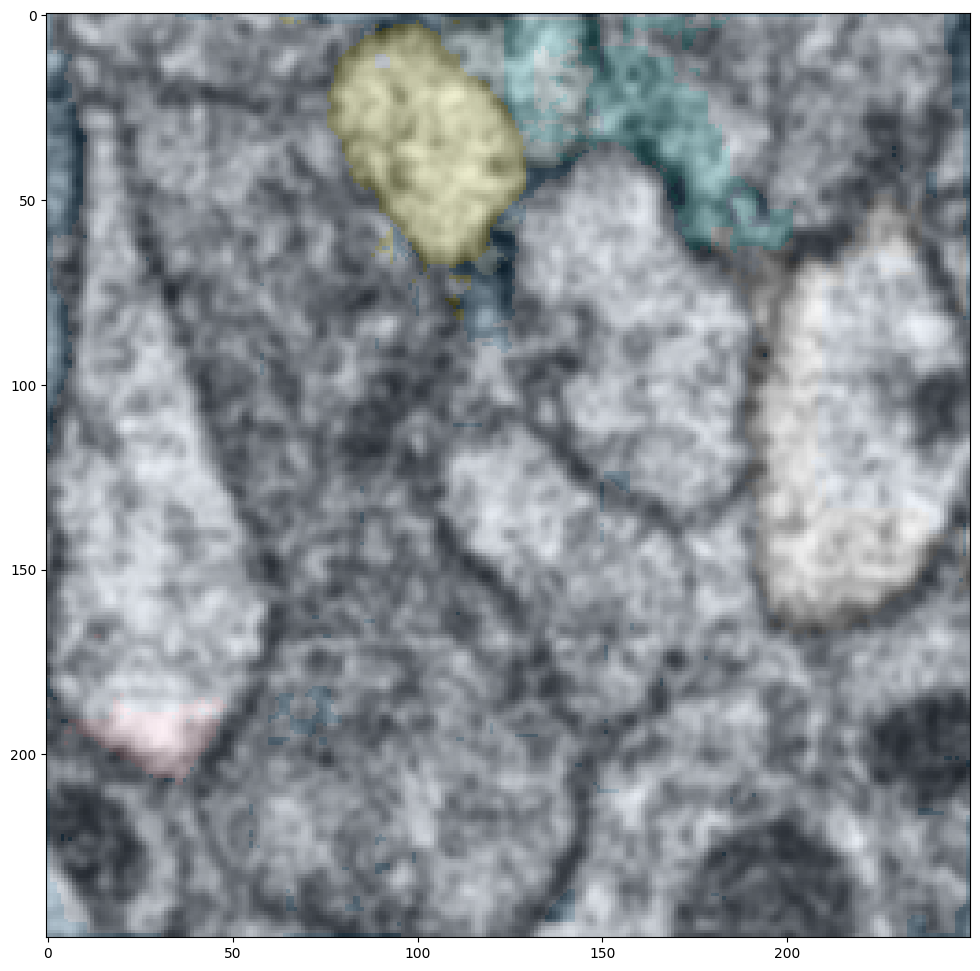

In [77]:

frame = 225
plt.figure(1, figsize=(12,12))
plt.imshow(cropped_image_zyx[frame,:,:], cmap='gray')
plt.imshow(colonramos_seg_zyx[frame,:,:], cmap='tab20', alpha=0.2)

In [87]:
cropped_image.mean()

118.13514496

In [88]:
cropped_image.std()

39.93944711124315